In [20]:
import pandas as pd

indicator_log_path = 'logs/6_2012 Subaru Impreza/indicator/6_indicator_CAN.log'
df_can = pd.read_csv(indicator_log_path, sep='\s+', header=None, names=['timestamp', 'bus', 'raw_frame'])
df_can['timestamp'] = df_can['timestamp'].str[1:-1].astype(float)
df_can['date'] = pd.to_datetime(pd.to_numeric(df_can['timestamp']), unit='s')
df_can['id'] = df_can['raw_frame'].str[0:3]
df_can['payload'] = df_can['raw_frame'].str[4:18]
df_can

# df_can[df_can['id']=='378']

,timestamp,bus,raw_frame,date,id,payload
0,1.721117e+09,can0,140#0006004000000B01,2024-07-16 08:07:44.417252064,140,0006004000000B
1,1.721117e+09,can0,141#1B262A2800803800,2024-07-16 08:07:44.417345047,141,1B262A28008038
2,1.721117e+09,can0,280#0003100000000000,2024-07-16 08:07:44.417351007,280,00031000000000
3,1.721117e+09,can0,148#0E1200804100FF01,2024-07-16 08:07:44.417357922,148,0E1200804100FF
4,1.721117e+09,can0,149#84013F009D000000,2024-07-16 08:07:44.417362928,149,84013F009D0000
...,...,...,...,...,...,...
166763,1.721117e+09,can0,002#FFEA700F68000000,2024-07-16 08:10:11.171035051,002,FFEA700F680000
166764,1.721117e+09,can0,140#000C004000000C01,2024-07-16 08:10:11.171508074,140,000C004000000C
166765,1.721117e+09,can0,141#1B262F2800803800,2024-07-16 08:10:11.171742916,141,1B262F28008038
166766,1.721117e+09,can0,360#0000626BDF000000,2024-07-16 08:10:11.171991110,360,0000626BDF0000


In [2]:
indicator_annot_path = 'logs/6_2012 Subaru Impreza/indicator/6_indicator_annot.log'
df_annot = pd.read_csv(indicator_annot_path, sep=',', header=None, names=['timestamp', 'action'])
df_annot

,timestamp,action
0,1721117268,Left Indicator Off
1,1721117279,Left Indicator On
2,1721117290,Left Indicator Off
3,1721117301,Left Indicator On
4,1721117312,Left Indicator Off
5,1721117323,Left Indicator On
6,1721117334,Left Indicator Off
7,1721117345,Right Indicator On
8,1721117356,Right Indicator Off
9,1721117367,Right Indicator On


In [3]:
# 2. Isolate the target ID
target_id = '282'
df_282 = df_can[df_can['id'] == target_id].copy()

# 3. Create a function to find the "illuminated" payload in the time window
def get_payload_at_time(df, target_time):
    # Find all CAN messages broadcast in the 1 second after the switch was flipped
    mask = (df['timestamp'] >= target_time) & (df['timestamp'] <= target_time + 1.0)
    window_df = df[mask]
    
    if window_df.empty:
        return None
        
    # To avoid the "blinker problem" where we accidentally grab an 'off' frame,
    # we scan the 1-second window for any frame where Byte 5 isn't 00.
    for payload in window_df['payload']:
        if len(payload) == 16 and payload[10:12] != '00':
            return payload
            
    # If we don't find an active one (e.g., when turning it OFF), just return the first frame
    return window_df.iloc[0]['payload']

# 4. Cross-reference the annotations with the CAN traffic
results = []
for index, row in df_annot.iterrows():
    action_time = row['timestamp']
    action_name = row['action']
    
    payload = get_payload_at_time(df_282, action_time)
    
    if payload and len(payload) == 16: # Ensure we have a full 8-byte payload
        # Extract Byte 5 (characters 10 and 11 of the 16-character hex string)
        byte_5_hex = payload[10:12]
        
        # Convert hex to an 8-bit binary string for visualization
        byte_5_bin = bin(int(byte_5_hex, 16))[2:].zfill(8)
        
        results.append({
            'Action': action_name,
            'Time': action_time,
            'Full Payload': payload,
            'Byte 5 (Hex)': byte_5_hex,
            'Byte 5 (Bin)': byte_5_bin
        })

# 5. Display the verification table
df_results = pd.DataFrame(results)
print(f"--- Verification for CAN ID {target_id} ---")
df_results

--- Verification for CAN ID 282 ---


""


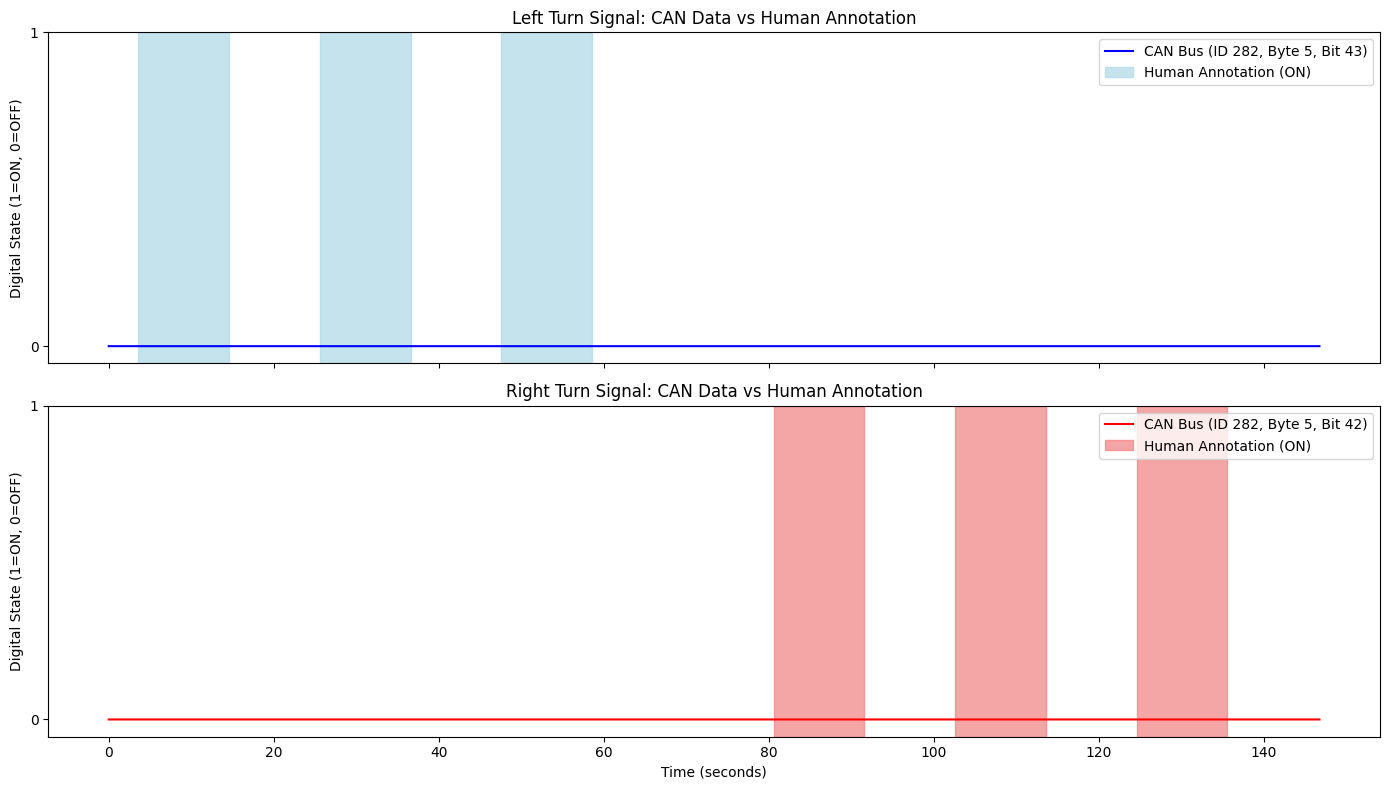

In [4]:
import matplotlib.pyplot as plt

# 1. Filter the CAN data for ID 282
df_282 = df_can[df_can['id'] == '282'].copy()

# 2. Extract the Left and Right bit states from Byte 5
# Hex '10' is 00010000 (Left), Hex '20' is 00100000 (Right)
def get_signal_states(payload):
    if len(payload) == 16:
        try:
            byte_5_val = int(payload[10:12], 16)
            left_state = 1 if (byte_5_val & 0x10) else 0
            right_state = 1 if (byte_5_val & 0x20) else 0
            return left_state, right_state
        except ValueError:
            pass
    return 0, 0

df_282['left_signal'], df_282['right_signal'] = zip(*df_282['payload'].apply(get_signal_states))

# Normalize timestamps to start at 0 for easier reading
start_time = min(df_282['timestamp'].min(), df_annot['timestamp'].min())
df_282['rel_time'] = df_282['timestamp'] - start_time
df_annot['rel_time'] = df_annot['timestamp'] - start_time

# 3. Prepare the plotting window
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# --- PLOT 1: LEFT SIGNAL ---
# Plot the actual CAN bus data
ax1.step(df_282['rel_time'], df_282['left_signal'], where='post', color='blue', label='CAN Bus (ID 282, Byte 5, Bit 43)')

# Overlay the human annotations as shaded regions
left_on_times = df_annot[df_annot['action'] == 'Left Indicator On']['rel_time'].tolist()
left_off_times = df_annot[df_annot['action'] == 'Left Indicator Off']['rel_time'].tolist()

for i in range(min(len(left_on_times), len(left_off_times))):
    label = 'Human Annotation (ON)' if i == 0 else ""
    ax1.axvspan(left_on_times[i], left_off_times[i], color='lightblue', alpha=0.7, label=label)

ax1.set_title('Left Turn Signal: CAN Data vs Human Annotation')
ax1.set_ylabel('Digital State (1=ON, 0=OFF)')
ax1.set_yticks([0, 1])
ax1.legend(loc='upper right')

# --- PLOT 2: RIGHT SIGNAL ---
# Plot the actual CAN bus data
ax2.step(df_282['rel_time'], df_282['right_signal'], where='post', color='red', label='CAN Bus (ID 282, Byte 5, Bit 42)')

# Overlay the human annotations as shaded regions
right_on_times = df_annot[df_annot['action'] == 'Right Indicator On']['rel_time'].tolist()
right_off_times = df_annot[df_annot['action'] == 'Right Indicator Off']['rel_time'].tolist()

for i in range(min(len(right_on_times), len(right_off_times))):
    label = 'Human Annotation (ON)' if i == 0 else ""
    ax2.axvspan(right_on_times[i], right_off_times[i], color='lightcoral', alpha=0.7, label=label)

ax2.set_title('Right Turn Signal: CAN Data vs Human Annotation')
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Digital State (1=ON, 0=OFF)')
ax2.set_yticks([0, 1])
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

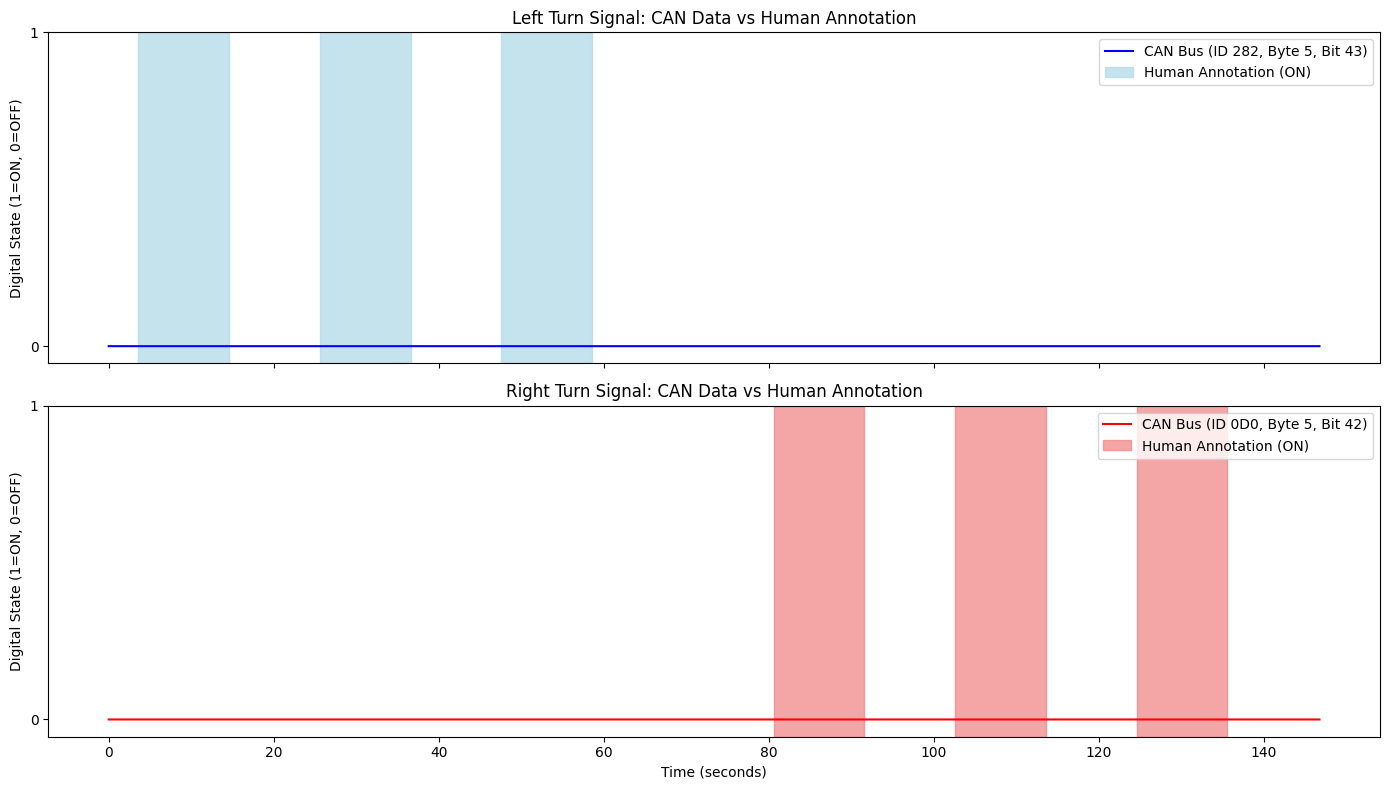

In [5]:
import matplotlib.pyplot as plt

# 1. Filter the CAN data for ID 282
df_0D0 = df_can[df_can['id'] == '0D0'].copy()

# 2. Extract the Left and Right bit states from Byte 5
# Hex '10' is 00010000 (Left), Hex '20' is 00100000 (Right)
def get_signal_states(payload):
    if len(payload) == 16:
        try:
            byte_5_val = int(payload[10:12], 16)
            left_state = 1 if (byte_5_val & 0x10) else 0
            right_state = 1 if (byte_5_val & 0x20) else 0
            return left_state, right_state
        except ValueError:
            pass
    return 0, 0

df_0D0['left_signal'], df_0D0['right_signal'] = zip(*df_0D0['payload'].apply(get_signal_states))

# Normalize timestamps to start at 0 for easier reading
start_time = min(df_0D0['timestamp'].min(), df_annot['timestamp'].min())
df_0D0['rel_time'] = df_0D0['timestamp'] - start_time
df_annot['rel_time'] = df_annot['timestamp'] - start_time

# 3. Prepare the plotting window
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# --- PLOT 1: LEFT SIGNAL ---
# Plot the actual CAN bus data
ax1.step(df_0D0['rel_time'], df_0D0['left_signal'], where='post', color='blue', label='CAN Bus (ID 282, Byte 5, Bit 43)')

# Overlay the human annotations as shaded regions
left_on_times = df_annot[df_annot['action'] == 'Left Indicator On']['rel_time'].tolist()
left_off_times = df_annot[df_annot['action'] == 'Left Indicator Off']['rel_time'].tolist()

for i in range(min(len(left_on_times), len(left_off_times))):
    label = 'Human Annotation (ON)' if i == 0 else ""
    ax1.axvspan(left_on_times[i], left_off_times[i], color='lightblue', alpha=0.7, label=label)

ax1.set_title('Left Turn Signal: CAN Data vs Human Annotation')
ax1.set_ylabel('Digital State (1=ON, 0=OFF)')
ax1.set_yticks([0, 1])
ax1.legend(loc='upper right')

# --- PLOT 2: RIGHT SIGNAL ---
# Plot the actual CAN bus data
ax2.step(df_0D0['rel_time'], df_0D0['right_signal'], where='post', color='red', label='CAN Bus (ID 0D0, Byte 5, Bit 42)')

# Overlay the human annotations as shaded regions
right_on_times = df_annot[df_annot['action'] == 'Right Indicator On']['rel_time'].tolist()
right_off_times = df_annot[df_annot['action'] == 'Right Indicator Off']['rel_time'].tolist()

for i in range(min(len(right_on_times), len(right_off_times))):
    label = 'Human Annotation (ON)' if i == 0 else ""
    ax2.axvspan(right_on_times[i], right_off_times[i], color='lightcoral', alpha=0.7, label=label)

ax2.set_title('Right Turn Signal: CAN Data vs Human Annotation')
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Digital State (1=ON, 0=OFF)')
ax2.set_yticks([0, 1])
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_can_bits(df_can, df_annot, target_id, bit_positions):
    """
    Extracts and plots specific bit positions for a given CAN ID,
    overlaying human annotations as shaded regions.
    """
    
    # 1. Filter the CAN data for the target ID
    df_filtered = df_can[df_can['id'] == target_id].copy()
    print(len(df_filtered))
    if df_filtered.empty:
        print(f"No data found for ID {target_id}")
        return

    # 2. Helper to extract bits from hex payload
    def get_bit_state(payload, bit_idx):
        if pd.isna(payload) or len(payload) == 0:
            return 0
        try:
            # Convert hex to binary, padding to the full byte length (2 hex chars = 8 bits)
            expected_bits = len(payload) * 4
            bin_str = bin(int(payload, 16))[2:].zfill(expected_bits)
            
            # CAN bits are often indexed from the left (MSB) or right (LSB)
            # This follows standard string indexing (0 is the very first bit of the payload)
            if bit_idx < len(bin_str):
                return int(bin_str[bit_idx])
        except ValueError:
            pass
        return 0

    for bit in bit_positions:
        col_name = f'bit_{bit}'
        df_filtered[col_name] = df_filtered['payload'].apply(lambda x: get_bit_state(x, bit))

    # 3. Synchronize Timestamps
    start_time = min(df_filtered['timestamp'].min(), df_annot['timestamp'].min())
    df_filtered['rel_time'] = df_filtered['timestamp'] - start_time
    
    # 4. Process Human Annotations into valid Start-End pairs
    # This prevents the "backwards" or shifted shading issue
    df_a = df_annot.sort_values('timestamp').copy()
    df_a['rel_time'] = df_a['timestamp'] - start_time

    intervals = []
    temp_on_time = None

    for _, row in df_a.iterrows():
        action = str(row['action']).strip().lower()
        if 'on' in action:
            temp_on_time = row['rel_time']
        elif 'off' in action and temp_on_time is not None:
            intervals.append((temp_on_time, row['rel_time']))
            temp_on_time = None # Reset to look for the next "On"

    # 5. Dynamic Plotting
    num_plots = len(bit_positions)
    fig, axes = plt.subplots(num_plots, 1, figsize=(14, 4 * num_plots), sharex=True)
    
    if num_plots == 1:
        axes = [axes]
        
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    for i, bit in enumerate(bit_positions):
        ax = axes[i]
        col_name = f'bit_{bit}'
        color = colors[i % len(colors)]
        
        # Plot the CAN bus data as a step function
        ax.step(df_filtered['rel_time'], df_filtered[col_name], where='post', 
                color=color, linewidth=2, label=f'CAN ID {target_id} | Bit {bit}')

        # Overlay the processed annotation intervals
        for j, (start, end) in enumerate(intervals):
            label = 'Human Annotation (Active)' if j == 0 else ""
            ax.axvspan(start, end, color='gray', alpha=0.3, label=label)

        ax.set_title(f'Digital State Analysis: Bit {bit}')
        ax.set_ylabel('State (1/0)')
        ax.set_yticks([0, 1])
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.legend(loc='upper right')

    axes[-1].set_xlabel('Relative Time (seconds)')
    plt.tight_layout()
    plt.show()

888
147


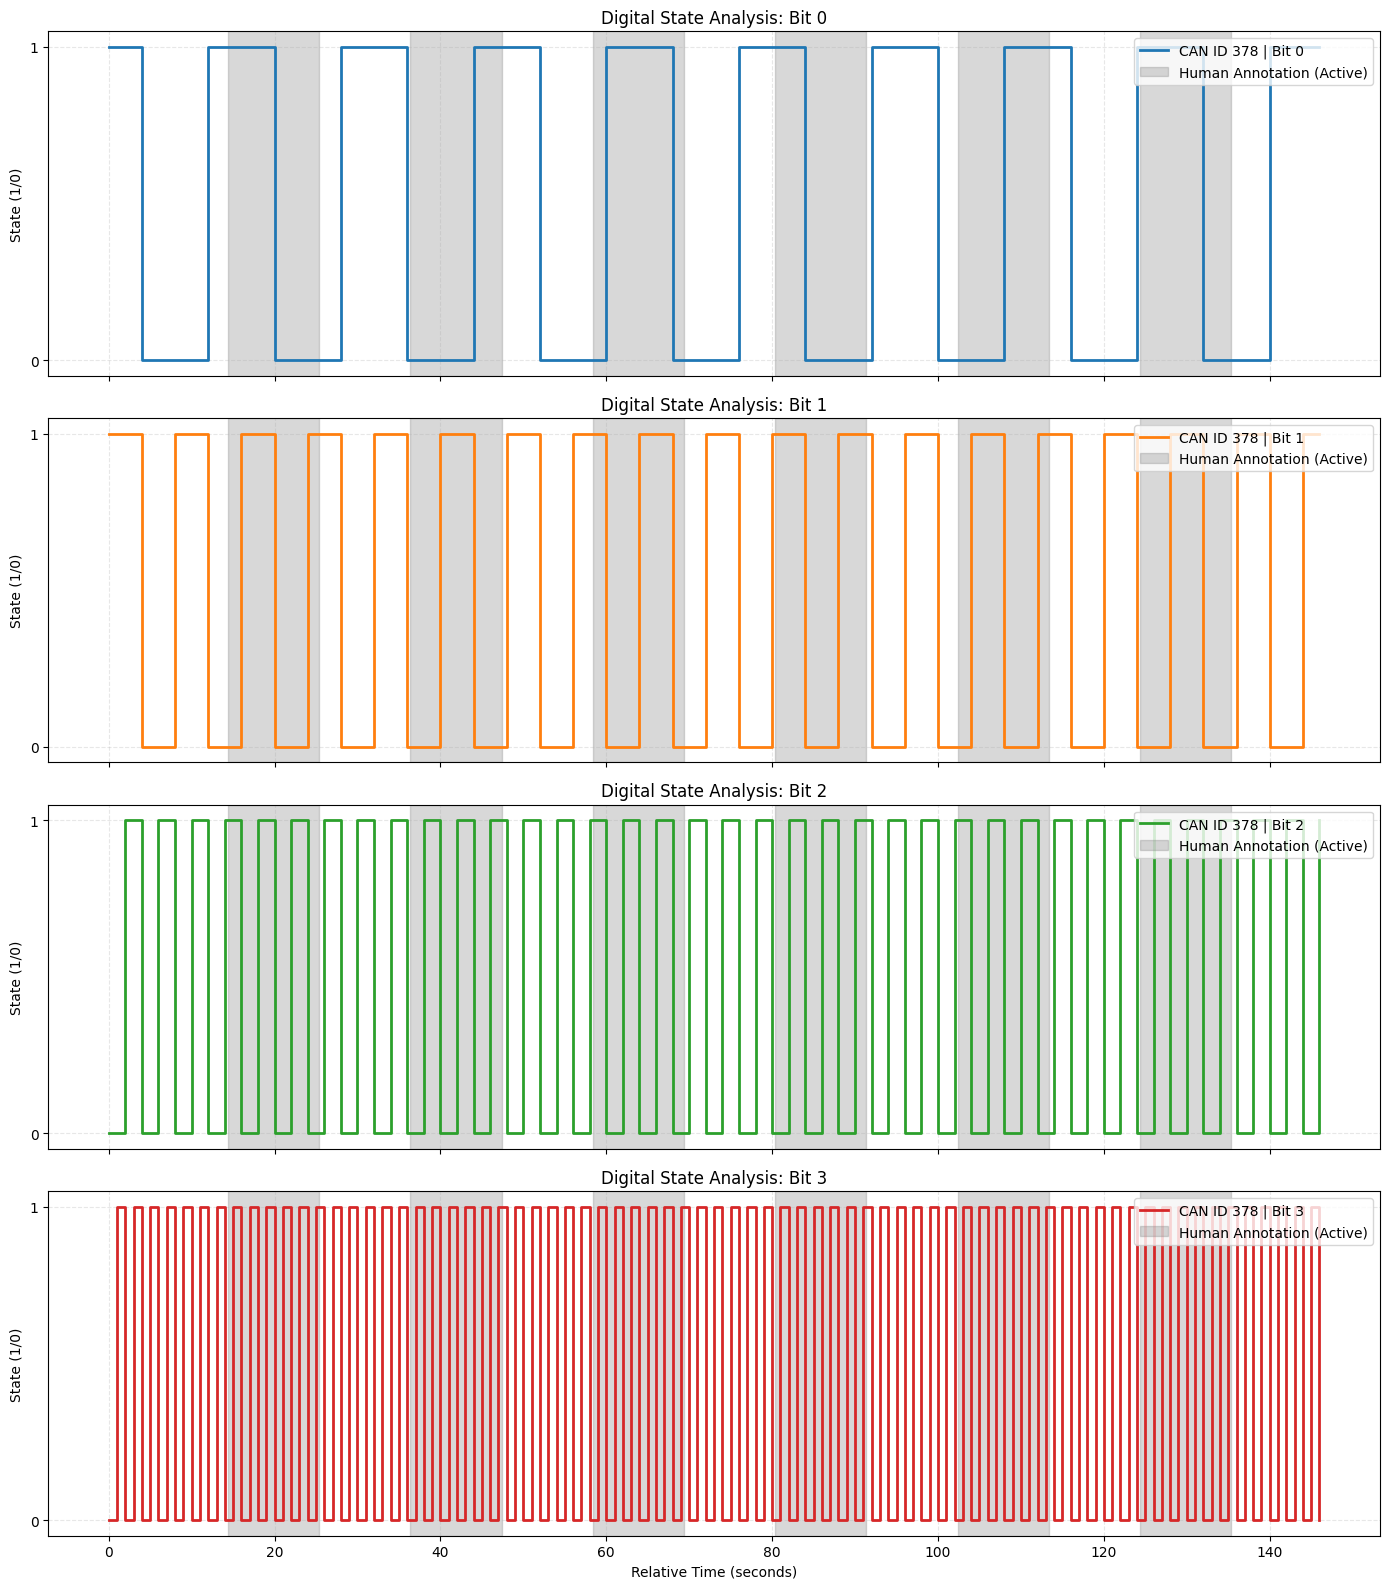

In [7]:
print(int(0x378))
plot_can_bits(df_can, df_annot, target_id='378', bit_positions=[0,1,2,3])


642
2939


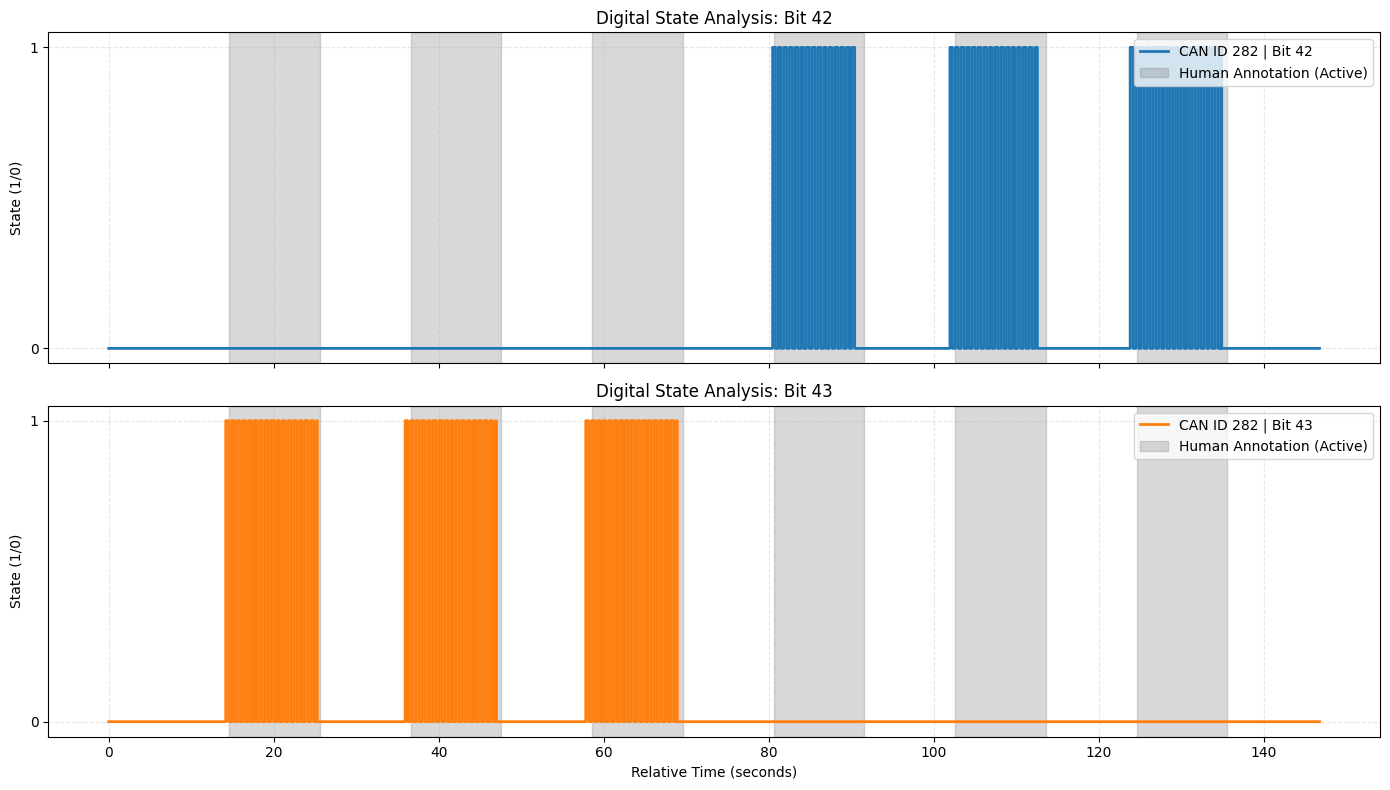

In [8]:
print(int(0x282))
plot_can_bits(df_can, df_annot, target_id='282', bit_positions=[42, 43])

2
14704


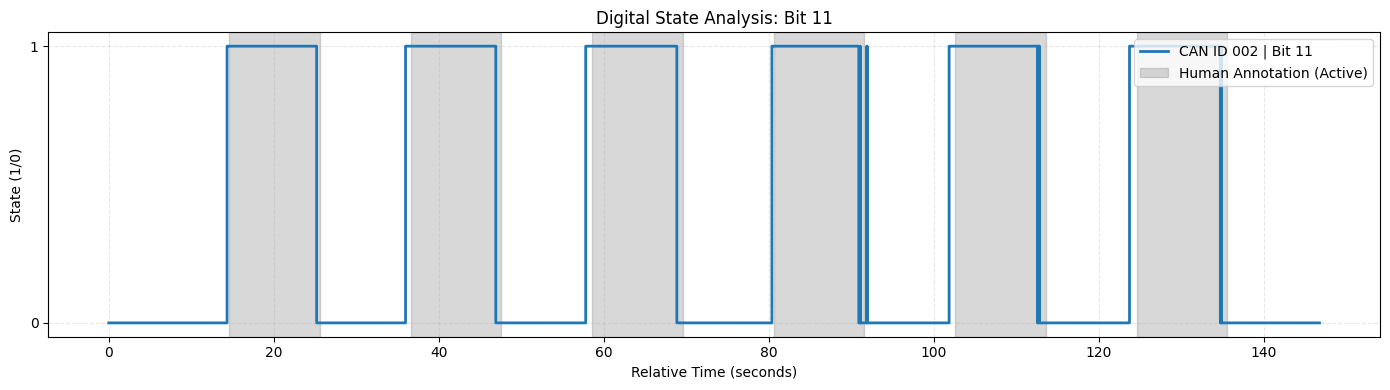

In [9]:
print(int(0x002))
plot_can_bits(df_can, df_annot, target_id='002', bit_positions=[11])

In [10]:

plot_can_counter(df_can[10000:15000], '002', start_bit=36, num_bits=3)

plot_can_counter(df_can[10000:15000], '002', start_bit=28, num_bits=3)

plot_can_counter(df_can[10000:15000], '002', start_bit=, num_bits=3)

plot_can_counter(df_can[10000:15000], '002', start_bit=36, num_bits=3)

# plot_can_counter(df_can[10000:15000], '002', start_bit=39, num_bits=64)


# plot_can_counter(df_can[10000:15000], '002', start_bit=0, num_bits=8)
# plot_can_counter(df_can[10000:15000], '002', start_bit=7, num_bits=16, endian='little')
# plot_can_counter(df_can[10000:15000], '002', start_bit=16, num_bits=8, endian='little')
# plot_can_counter(

SyntaxError: invalid syntax (1750779329.py, line 5)

In [ ]:
# 1. Filter the data
target_id = '378'
df_filtered = df_can[df_can['id'] == target_id].copy()

# 2. Define the extraction helper (Universal for hex payloads)
def get_bit_state(payload, bit_idx):
    if pd.isna(payload) or not payload: return 0
    try:
        # Padded binary string (each hex char is 4 bits)
        bin_str = bin(int(payload, 16))[2:].zfill(len(payload) * 4)
        return int(bin_str[bit_idx]) if bit_idx < len(bin_str) else 0
    except: return 0

# 3. Create the bit columns FIRST (This fixes the KeyError)
for b in range(4):
    df_filtered[f'bit_{b}'] = df_filtered['payload'].apply(lambda x: get_bit_state(x, b))

# 4. Now calculate the 4-bit integer value
df_filtered['counter_value'] = (
    df_filtered['bit_0'] * 8 + 
    df_filtered['bit_1'] * 4 + 
    df_filtered['bit_2'] * 2 + 
    df_filtered['bit_3'] * 1
)

# 5. Plot the result
plt.figure(figsize=(14, 5))
plt.step(df_filtered['timestamp'] - df_filtered['timestamp'].min(), 
         df_filtered['counter_value'], where='post', color='black', lw=2)

plt.title(f"Decimal Value of 4-Bit Counter (ID {target_id})")
plt.ylabel("Value (0-15)")
plt.xlabel("Time (seconds)")
plt.yticks(range(16))
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
def plot_can_counter(df_can, target_id, start_bit=0, num_bits=4):
    """
    Extracts a range of bits from a CAN ID, converts them to a decimal 
    integer (MSB first), and plots the resulting counter.
    """
    # 1. Filter and prepare data
    df_f = df_can[df_can['id'] == target_id].copy()
    if df_f.empty:
        print(f"No data found for ID {target_id}")
        return

    # 2. Define the extraction helper
    def get_bit_state(payload, bit_idx):
        if pd.isna(payload) or not payload: return 0
        try:
            # Padded binary string (4 bits per hex char)
            bin_str = bin(int(payload, 16))[2:].zfill(len(payload) * 4)
            return int(bin_str[bit_idx]) if bit_idx < len(bin_str) else 0
        except: return 0

    # 3. Extract bits and calculate decimal value
    # We use a running sum to calculate the decimal value: Σ (bit * 2^exponent)
    df_f['counter_value'] = 0
    for i in range(num_bits):
        global_bit_idx = start_bit + i
        bit_series = df_f['payload'].apply(lambda x: get_bit_state(x, global_bit_idx))
        
        # Power calculation assumes MSB is the first bit in the range (Big Endian)
        power = num_bits - 1 - i
        df_f['counter_value'] += bit_series * (2 ** power)

    # 4. Plotting
    plt.figure(figsize=(14, 5))
    rel_time = df_f['timestamp'] - df_f['timestamp'].min()
    
    plt.step(rel_time, df_f['counter_value'], where='post', color='black', lw=2)

    plt.title(f"Decimal Value of {num_bits}-Bit Counter (ID {target_id}, Bits {start_bit}-{start_bit+num_bits-1})")
    plt.ylabel(f"Value (0-{2**num_bits - 1})")
    plt.xlabel("Time (seconds)")
    plt.yticks(range(2**num_bits))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
plot_can_counter(df_can, '378', start_bit=0, num_bits=5)

In [ ]:
plot_can_bits(df_can, df_annot, target_id='002', bit_positions=[5])

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_can_counter(df_can, target_id, start_bit=0, num_bits=4, endian='big'):
    """
    Extracts a range of bits and plots them as a decimal counter.
    
    Parameters:
    - endian='big': The first bit (start_bit) is the Most Significant Bit (MSB).
    - endian='little': The first bit (start_bit) is the Least Significant Bit (LSB).
    """
    df_f = df_can[df_can['id'] == target_id].copy().sort_values('timestamp')
    if df_f.empty:
        return print(f"No data found for ID {target_id}")

    def get_bit_state(payload, bit_idx):
        if pd.isna(payload) or not payload: return 0
        try:
            # Padded binary string (4 bits per hex char)
            bin_str = bin(int(payload, 16))[2:].zfill(len(payload) * 4)
            return int(bin_str[bit_idx]) if bit_idx < len(bin_str) else 0
        except: return 0

    # Calculate decimal value based on endianness
    df_f['counter_value'] = 0
    for i in range(num_bits):
        current_bit_idx = start_bit + i
        bit_series = df_f['payload'].apply(lambda x: get_bit_state(x, current_bit_idx))
        
        if endian.lower() == 'big':
            # First bit has the highest weight (e.g., 2^3, 2^2, 2^1, 2^0)
            power = num_bits - 1 - i
        else:
            # First bit has the lowest weight (e.g., 2^0, 2^1, 2^2, 2^3)
            power = i
            
        df_f['counter_value'] += bit_series * (2 ** power)

    # Plotting
    plt.figure(figsize=(14, 5))
    rel_time = df_f['timestamp'] - df_f['timestamp'].min()
    plt.step(rel_time, df_f['counter_value'], where='post', color='black', lw=2)

    plt.title(f"ID {target_id} | {num_bits}-Bit Counter ({endian.capitalize()} Endian)")
    plt.ylabel(f"Decimal Value (0-{2**num_bits - 1})")
    plt.xlabel("Time (seconds)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
plot_can_counter(df_can, target_id, start_bit=0, num_bits=4, endian='big')

In [ ]:
plot_can_counter(df_can, target_id, start_bit=0, num_bits=5, endian='big')

In [ ]:
print(hex(152))
plot_can_counter(df_can, '098', start_bit=0, num_bits=5, endian='big')

In [ ]:
# From CAN subaru 2015 DBC- 642 Dashlights 
target = 642
target_hex = hex(target)
print(target_hex,str(target_hex)[2:])
target_id=str(target_hex)[2:]

# COUNTER : stated (12|4@1+) Actual: 8|4@1+
plot_can_counter(df_can[100:10000], target_id, start_bit=8, num_bits=4, endian='big')

In [ ]:
plot_can_counter(df_can, target_id, start_bit=38, num_bits=1, endian='big')

In [ ]:
indicator_log_path = 'logs/6_2012 Subaru Impreza/driving/6_driving_CAN.log'
df_can = pd.read_csv(indicator_log_path, sep='\s+', header=None, names=['timestamp', 'bus', 'raw_frame'])
df_can['id'] = df_can['raw_frame'].str[0:3]
df_can['timestamp'] = df_can['timestamp'].str[1:-1].astype(float)
df_can['payload'] = df_can['raw_frame'].str[4:18]
df_can

In [ ]:
plot_can_counter(df_can, target_id, start_bit=38, num_bits=1, endian='big')

In [ ]:
!pip install antropy

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import antropy as ant 

def analyze_can_id_entropy(df, target_id, sample_size=1000):
    """
    Analyzes and plots Shannon Entropy, Bit-Flip Rate, and Sample Entropy 
    for a specific CAN ID.
    """
    # 1. Filter and Prepare Data
    df_id = df[df['id'] == target_id].copy()
    
    if df_id.empty:
        print(f"Error: ID {target_id} not found in dataframe.")
        return

    def hex_to_bits(hex_str):
        # Dynamically calculate bit length based on hex string (usually 64 for 8 bytes)
        bit_len = len(hex_str) * 4
        return bin(int(hex_str, 16))[2:].zfill(bit_len)

    bit_series = df_id['payload'].apply(hex_to_bits)
    bits_df = pd.DataFrame([list(b) for b in bit_series]).astype(int)
    num_bits = bits_df.shape[1]

    # --- Metrics Functions ---
    def calc_shannon(col):
        p = col.value_counts(normalize=True)
        return -np.sum(p * np.log2(p)) if len(p) > 1 else 0

    def calc_flip_rate(col):
        return col.diff().abs().mean()

    def calc_sample_entropy(col):
        try:
            if col.std() == 0: return 0
            # Sample size limited for speed
            return ant.sample_entropy(col.values[:sample_size])
        except:
            return 0

    # 2. Calculate Metrics
    print(f"Analyzing ID {target_id} ({len(df_id)} frames)...")
    metrics = pd.DataFrame({
        'Shannon': bits_df.apply(calc_shannon),
        'FlipRate': bits_df.apply(calc_flip_rate),
        'SampleEnt': bits_df.apply(calc_sample_entropy)
    })

    # 3. Visualize
    fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
    colors = ['teal', 'crimson', 'orchid']
    titles = [f'ID {target_id}: Shannon Entropy', 'Bit-Flip Rate', 'Sample Entropy (Complexity)']
    cols = ['Shannon', 'FlipRate', 'SampleEnt']

    for i, ax in enumerate(axes):
        ax.bar(range(num_bits), metrics[cols[i]], color=colors[i], alpha=0.8, width=0.8)
        ax.set_title(titles[i], fontweight='bold')
        ax.set_ylabel('Value')
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        ax.set_xticks(range(0, num_bits, 4))
        
    plt.xlabel('Bit Index')
    plt.tight_layout()
    plt.show()
    
    return metrics # Returning the dataframe for further numerical analysis

# Example Usage:
# metrics_002 = analyze_can_id_entropy(df_can, '002')
def analyze_can_id_entropy(df, target_id, sample_size=100000):
    """
    Analyzes and plots Shannon Entropy, Bit-Flip Rate, and Sample Entropy 
    for a specific CAN ID.
    """
    # 1. Filter and Prepare Data
    df_id = df[df['id'] == target_id].copy()
    
    if df_id.empty:
        print(f"Error: ID {target_id} not found in dataframe.")
        return

    # def hex_to_bits(hex_str):
    #     # Dynamically calculate bit length based on hex string (usually 64 for 8 bytes)
    #     bit_len = len(hex_str) * 4
    #     return bin(int(hex_str, 16))[2:].zfill(bit_len)
    def hex_to_bits(hex_str):
        # Convert to int, then to bin, strip '0b', 
        # and use zfill(64) to FORCE it to 64 bits.
        return bin(int(hex_str, 16))[2:].zfill(64)

    bit_series = df_id['payload'].apply(hex_to_bits)
    bits_df = pd.DataFrame([list(b) for b in bit_series]).astype(int)
    num_bits = bits_df.shape[1]

    # Plot the first 50 consecutive messages of ID 002
    plt.imshow(bits_df.iloc[:50, :], aspect='auto', cmap='binary')
    plt.title("True Chronological Bit Sequence: ID 002")

    # --- Metrics Functions ---
    def calc_shannon(col):
        p = col.value_counts(normalize=True)
        return -np.sum(p * np.log2(p)) if len(p) > 1 else 0

    def calc_flip_rate(col):
        return col.diff().abs().mean()

    def calc_sample_entropy(col):
        try:
            if col.std() == 0: return 0
            # Sample size limited for speed
            return ant.sample_entropy(col.values[:sample_size])
        except:
            return 0

    # 2. Calculate Metrics
    print(f"Analyzing ID {target_id} ({len(df_id)} frames)...")
    metrics = pd.DataFrame({
        'Shannon': bits_df.apply(calc_shannon),
        'FlipRate': bits_df.apply(calc_flip_rate),
        'SampleEnt': bits_df.apply(calc_sample_entropy)
    })

    # 3. Visualize
    fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
    colors = ['teal', 'crimson', 'orchid']
    titles = [f'ID {target_id}: Shannon Entropy', 'Bit-Flip Rate', 'Sample Entropy (Complexity)']
    cols = ['Shannon', 'FlipRate', 'SampleEnt']

    for i, ax in enumerate(axes):
        ax.bar(range(num_bits), metrics[cols[i]], color=colors[i], alpha=0.8, width=0.8)
        ax.set_title(titles[i], fontweight='bold')
        ax.set_ylabel('Value')
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        ax.set_xticks(range(0, num_bits, 4))
        
    plt.xlabel('Bit Index')
    plt.tight_layout()
    plt.show()
    
    return metrics # Returning the dataframe for further numerical analysis

# Example Usage:
metrics_002 = analyze_can_id_entropy(df_can, '002')

In [ ]:
print(metrics_002)

In [ ]:
def hex_to_bits(hex_str):
    # Force padding to 64 bits regardless of string length
    return bin(int(hex_str, 16))[2:].zfill(64)

df_002['raw_frame']

In [ ]:
print(hex(208))

metrics_0d0 = analyze_can_id_entropy(df_can, '0D0')

In [ ]:
print(hex(209))

metrics_0d1 = analyze_can_id_entropy(df_can, '0D1')

In [ ]:
print(hex(642))

metrics_282 = analyze_can_id_entropy(df_can, '282')

In [ ]:
print(hex(880))

metrics_370 = analyze_can_id_entropy(df_can, '370')

In [ ]:
print(hex(320))

metrics_140 = analyze_can_id_entropy(df_can, '140')

In [ ]:
print(hex(338))
metrics_152 = analyze_can_id_entropy(df_can, '152')

In [ ]:
print(hex(880))
metrics_370 = analyze_can_id_entropy(df_can, '370')

In [ ]:
print(hex(642))
metrics_282 = analyze_can_id_entropy(df_can, '282')